Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

import cv2
import re
import pytesseract

# Adiciona esta linha com o caminho onde instalaste o Tesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'


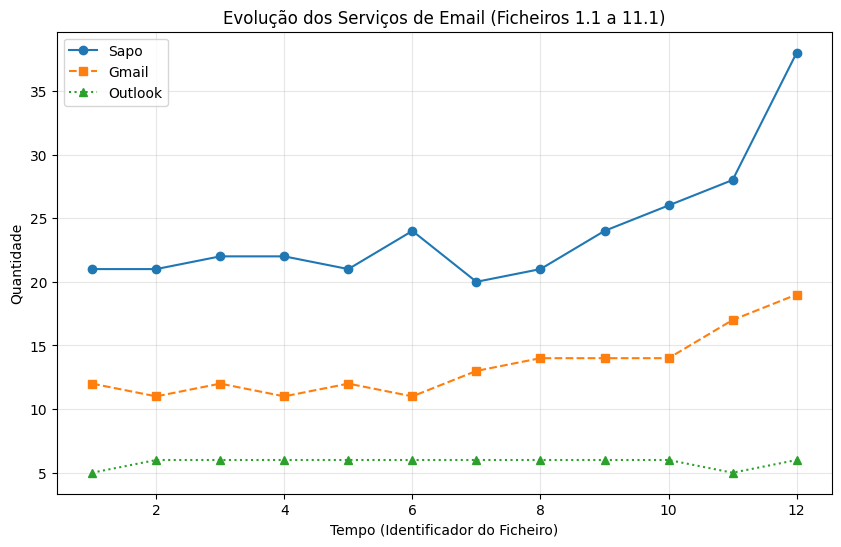

In [2]:
# Estrutura para armazenar os dados
dados = {"Tempo": [], "Sapo": [], "Gmail": [], "Outlook": []}

# 1. Loop para ler os 11 ficheiros
for x in range(1, 13):
    filename = f"TemposEmails/{x}.1.txt"
    
    # Adicionamos o marcador de tempo
    dados["Tempo"].append(x)
    
    # Valores temporários para este ficheiro (caso falte algum dado no txt)
    valores_ficheiro = {"Sapo": 0, "Gmail": 0, "Outlook": 0}
    
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            for linha in f:
                if "=" in linha:
                    servico, valor = linha.split("=")
                    servico = servico.strip()
                    valor = int(valor.strip())
                    if servico in valores_ficheiro:
                        valores_ficheiro[servico] = valor
    
    # Adicionar aos dados principais
    dados["Sapo"].append(valores_ficheiro["Sapo"])
    dados["Gmail"].append(valores_ficheiro["Gmail"])
    dados["Outlook"].append(valores_ficheiro["Outlook"])

# 2. Criar um DataFrame para facilitar a manipulação
df = pd.DataFrame(dados)

# 3. Construir o Gráfico
plt.figure(figsize=(10, 6))
plt.plot(df["Tempo"], df["Sapo"], label="Sapo", marker='o', linestyle='-')
plt.plot(df["Tempo"], df["Gmail"], label="Gmail", marker='s', linestyle='--')
plt.plot(df["Tempo"], df["Outlook"], label="Outlook", marker='^', linestyle=':')

plt.title("Evolução dos Serviços de Email (Ficheiros 1.1 a 11.1)")
plt.xlabel("Tempo (Identificador do Ficheiro)")
plt.ylabel("Quantidade")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

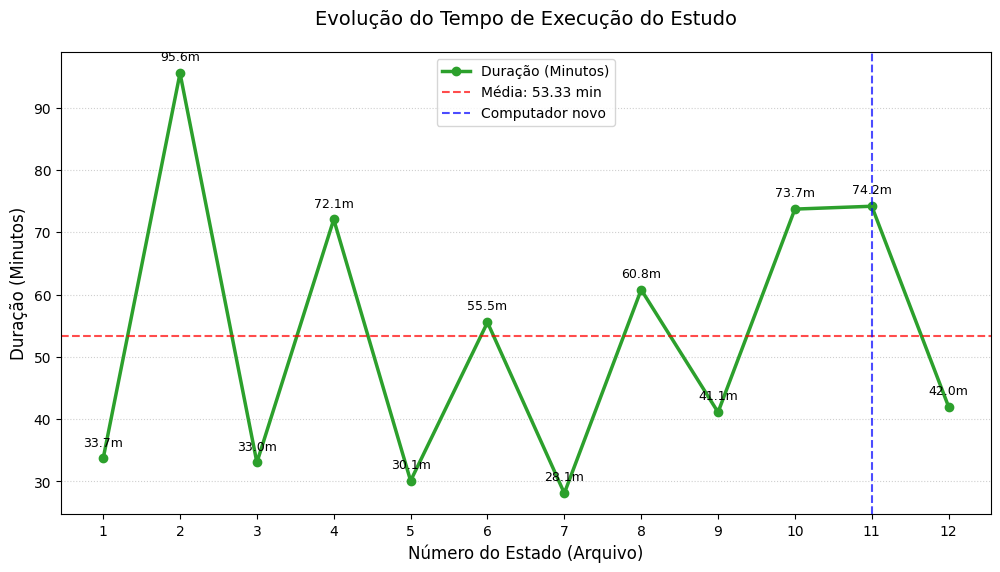

In [7]:
import matplotlib.pyplot as plt
import numpy as np

vetor_tempos_raw = [
    "33:41.68", "01:35;33.32", "33;02.84", "01:12:04.56", 
    "30:06.37", "55:32.63", "28:06.55", "01:00:47.51", 
    "41:07.04", "01:13:44.20", "01:14:11.56","41:59.49"
]

def converter_para_minutos(tempo_str):
    # Padroniza separadores
    tempo_limpo = tempo_str.replace(';', ':').replace(',', '.')
    partes = tempo_limpo.split(':')
    
    if len(partes) == 3:  # HH:MM:SS.CC
        h, m, s = partes
        segundos_totais = int(h) * 3600 + int(m) * 60 + float(s)
    elif len(partes) == 2:  # MM:SS.CC
        m, s = partes
        segundos_totais = int(m) * 60 + float(s)
    else:
        return 0
    
    return segundos_totais / 60  # Conversão final para minutos

# 1. Preparação dos dados
tempos_minutos = [converter_para_minutos(t) for t in vetor_tempos_raw]
media_minutos = np.mean(tempos_minutos)
indices = np.arange(1, len(tempos_minutos) + 1)

# 2. Construção do Gráfico
plt.figure(figsize=(12, 6))

# Linha de Evolução
plt.plot(indices, tempos_minutos, marker='o', linestyle='-', color='#2ca02c', label='Duração (Minutos)', linewidth=2.5)

# Linha da Média
plt.axhline(y=media_minutos, color='red', linestyle='--', alpha=0.7, label=f'Média: {media_minutos:.2f} min')
plt.axvline(x=11, color='blue', linestyle='--', alpha=0.7, label=f'Computador novo')

# 3. Formatação e Estética
plt.title('Evolução do Tempo de Execução do Estudo', fontsize=14, pad=20)
plt.xlabel('Número do Estado (Arquivo)', fontsize=12)
plt.ylabel('Duração (Minutos)', fontsize=12)
plt.xticks(indices)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.legend()

# Adicionar os valores acima dos pontos
for i, valor in enumerate(tempos_minutos):
    plt.text(indices[i], valor + 2, f'{valor:.1f}m', ha='center', fontsize=9)


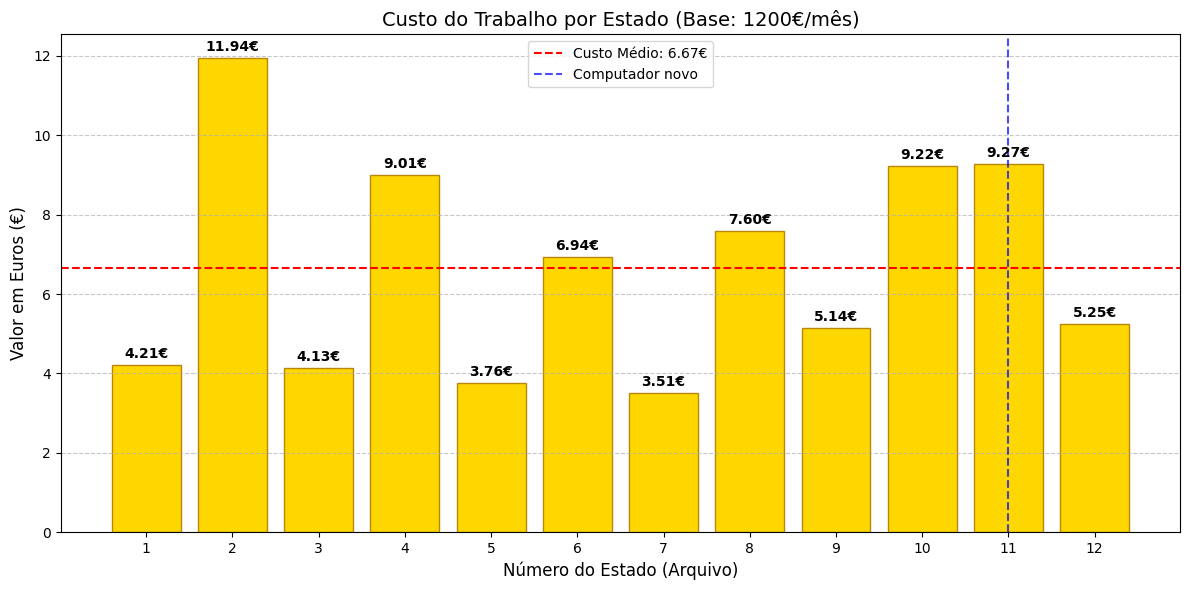

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def converter_para_minutos(tempo_str):
    tempo_limpo = tempo_str.replace(';', ':').replace(',', '.')
    partes = tempo_limpo.split(':')
    if len(partes) == 3: # HH:MM:SS
        return (int(partes[0]) * 3600 + int(partes[1]) * 60 + float(partes[2])) / 60
    elif len(partes) == 2: # MM:SS
        return (int(partes[0]) * 60 + float(partes[1])) / 60
    return 0

# 1. Processamento dos dados
tempos_minutos = [converter_para_minutos(t) for t in vetor_tempos_raw]
valor_por_minuto = 0.125 # (1200€ / 160h / 60min)
custos_euros = [m * valor_por_minuto for m in tempos_minutos]
indices = np.arange(1, len(custos_euros) + 1)

# 2. Criação do Gráfico
plt.figure(figsize=(12, 6))
bars = plt.bar(indices, custos_euros, color='gold', edgecolor='darkgoldenrod')

# Linha de custo médio
media_custo = np.mean(custos_euros)
plt.axhline(y=media_custo, color='red', linestyle='--', label=f'Custo Médio: {media_custo:.2f}€')
plt.axvline(x=11, color='blue', linestyle='--', alpha=0.7, label=f'Computador novo')

# 3. Estética
plt.title('Custo do Trabalho por Estado (Base: 1200€/mês)', fontsize=14)
plt.xlabel('Número do Estado (Arquivo)', fontsize=12)
plt.ylabel('Valor em Euros (€)', fontsize=12)
plt.xticks(indices)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar valores sobre as barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}€', ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()